# Spheres Profile With AMR Regions

Notebook wrapper for `spheres_profile_paper.py` using explicit MG/FMM run directories.

In [1]:
from pathlib import Path
import subprocess
import pandas as pd
import matplotlib.pyplot as plt

repo_root = Path("../..").resolve()
runs_dir = repo_root / "runs"

default_run_root = runs_dir / "amr_spheres_clean_serial_20260417_134657"
if default_run_root.exists():
    run_root = default_run_root
else:
    candidates = sorted(runs_dir.glob("amr_spheres_clean_serial_*"))
    if not candidates:
        raise FileNotFoundError("No runs/amr_spheres_clean_serial_* directory found.")
    run_root = candidates[-1]

fmm_run = run_root / "fmm"
mg_run = run_root / "mg"
out_base = repo_root / "analyze/spheres" / "spheres_profile_notebook"

print(f"run_root = {run_root}")
print(f"fmm_run  = {fmm_run}")
print(f"mg_run   = {mg_run}")
print(f"out_base = {out_base}")

run_root = /Users/jylee/Ramses-FMM/runs/amr_spheres_clean_serial_20260417_134657
fmm_run  = /Users/jylee/Ramses-FMM/runs/amr_spheres_clean_serial_20260417_134657/fmm
mg_run   = /Users/jylee/Ramses-FMM/runs/amr_spheres_clean_serial_20260417_134657/mg
out_base = /Users/jylee/Ramses-FMM/analyze/spheres/spheres_profile_notebook


In [2]:
cmd = [
    "python3",
    str(repo_root / "analyze/spheres/spheres_profile_paper.py"),
    "--case", f"FMM={fmm_run}",
    "--case", f"MG={mg_run}",
    "--nout", "2",
    "--slice-axis", "z",
    "--slice-center", "2.0",
    "--profile-coord", "2.0",
    "--output-base", str(out_base),
]
print("Running:")
print(" ".join(cmd))
res = subprocess.run(cmd, check=True, text=True, capture_output=True)
print(res.stdout)
if res.stderr.strip():
    print("STDERR:")
    print(res.stderr)

Running:
python3 /Users/jylee/Ramses-FMM/analyze/spheres/spheres_profile_paper.py --case FMM=/Users/jylee/Ramses-FMM/runs/amr_spheres_clean_serial_20260417_134657/fmm --case MG=/Users/jylee/Ramses-FMM/runs/amr_spheres_clean_serial_20260417_134657/mg --nout 2 --slice-axis z --slice-center 2.0 --profile-coord 2.0 --output-base /Users/jylee/Ramses-FMM/analyze/spheres/spheres_profile_notebook
ncpu=1 ndim=3 nlevelmax=9
Time= 0.0746613994034587
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 476344 leaf cells
Extracting leaf cells...
ncpu=1 ndim=3 nlevelmax=9
Time= 0.073941712595064
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 476344 leaf cells
Extracting leaf cells...
Wrote profile plot PNG: /Users/jylee/Ramses-FMM/analyze/spheres/spheres_profile_notebook_profile.png
Wrote profile plot PDF: /Users/jylee/Ramses-FMM/analyze/spheres/

In [3]:
summary_csv = out_base.with_name(out_base.name + "_summary.csv")
plot_png = out_base.with_name(out_base.name + "_profile.png")
plot_pdf = out_base.with_name(out_base.name + "_profile.pdf")

print(summary_csv)
print(plot_png)
print(plot_pdf)

df = pd.read_csv(summary_csv)
df

/Users/jylee/Ramses-FMM/analyze/spheres/spheres_profile_notebook_summary.csv
/Users/jylee/Ramses-FMM/analyze/spheres/spheres_profile_notebook_profile.png
/Users/jylee/Ramses-FMM/analyze/spheres/spheres_profile_notebook_profile.pdf


,case,ncell,mean_abs_rel,median_abs_rel,p95_abs_rel,max_abs_rel
0,FMM,556,0.000943,0.000547,0.004034,0.007680
1,MG,556,0.002642,0.000783,0.014689,0.025845


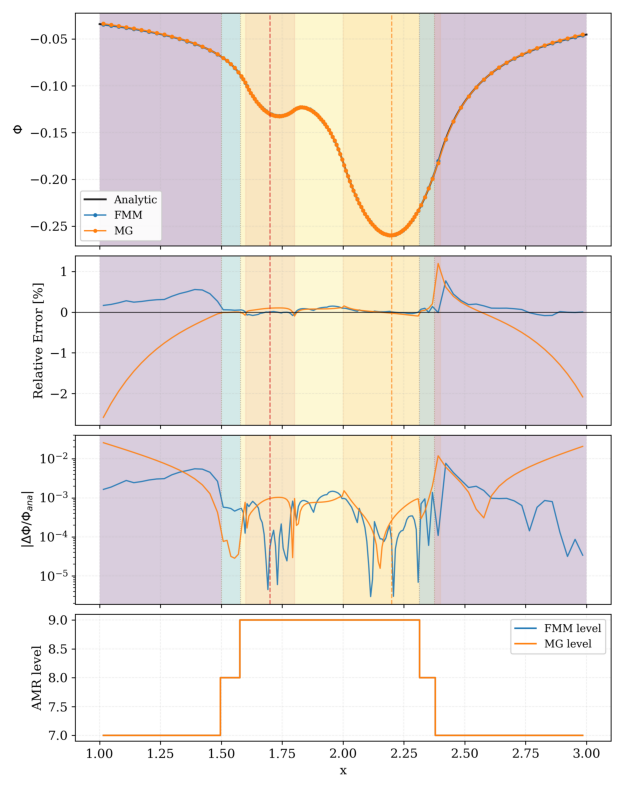

In [4]:
img = plt.imread(plot_png)
plt.figure(figsize=(9, 10))
plt.imshow(img)
plt.axis("off")
plt.show()